In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df = df.drop(columns=["id", "Unnamed: 32"])
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

The CSV has a trailing comma in its header that creates an empty `Unnamed: 32` column, and `id` is only an identifier, so both are dropped. Encode the target (`M` = malignant → 1, `B` = benign → 0) and split.

Unlike SVM or KNN, **no feature scaling is needed**: a tree splits on thresholds of one feature at a time, so the scale of a feature doesn't change which split is best.

In [4]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"].map({"B": 0, "M": 1})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((455, 30), (114, 30))

### 1. Gini vs entropy:

In [6]:
results = {}
for criterion in ["gini", "entropy"]:
    tree = DecisionTreeClassifier(criterion=criterion, random_state=42)
    tree.fit(X_train, y_train)
    results[criterion] = {
        "train accuracy": accuracy_score(y_train, tree.predict(X_train)),
        "test accuracy": accuracy_score(y_test, tree.predict(X_test)),
        "depth": tree.get_depth(),
        "leaves": tree.get_n_leaves(),
    }

pd.DataFrame(results).T.round(4)

,train accuracy,test accuracy,depth,leaves
gini,1.0,0.9298,8.0,24.0
entropy,1.0,0.9561,7.0,17.0


An unrestricted tree keeps splitting until every leaf is pure, so train accuracy is 100%. The gap to test accuracy is the overfitting we control next. Gini and entropy usually land close together; any small difference here comes from which splits each criterion happens to prefer on this particular split of the data.

### 2. Effect of `max_depth`:

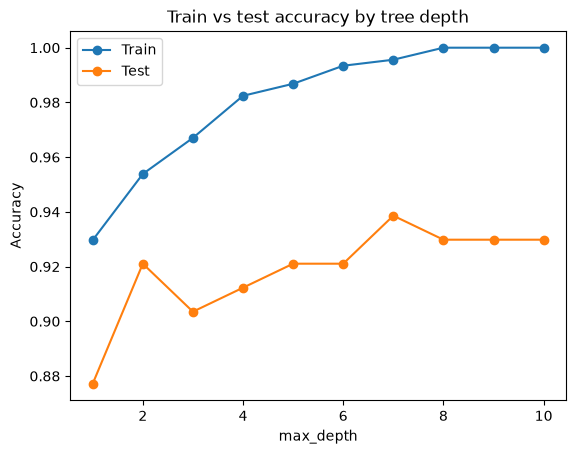

In [7]:
depths = range(1, 11)
train_acc, test_acc = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.plot(depths, train_acc, marker="o", label="Train")
plt.plot(depths, test_acc, marker="o", label="Test")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.title("Train vs test accuracy by tree depth")
plt.legend()
plt.show()

Train accuracy keeps climbing to 100% as the tree gets deeper, while test accuracy plateaus at roughly 92-93% from around depth 5. Extra depth only fits the training data more tightly.

### 3. Feature importances and a small tree:

A depth-3 tree gives up a few points of accuracy compared with deeper trees, but it is small enough to read, which is the point of this step.

In [8]:
final_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print("Test accuracy:", round(accuracy_score(y_test, final_tree.predict(X_test)), 4))

Test accuracy: 0.9035


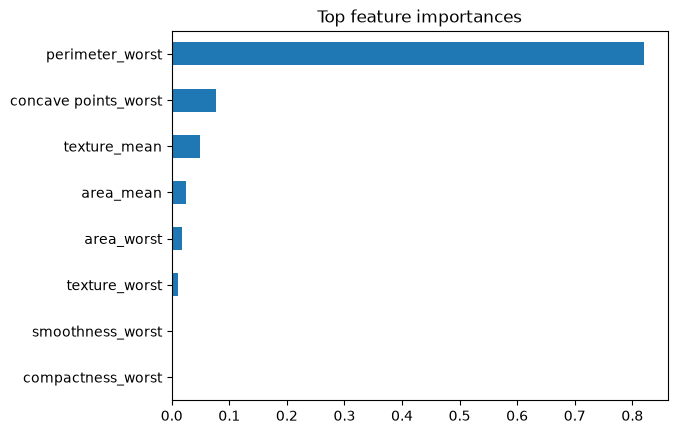

In [9]:
importances = pd.Series(final_tree.feature_importances_, index=X.columns)
importances.sort_values().tail(8).plot(kind="barh", title="Top feature importances")
plt.show()

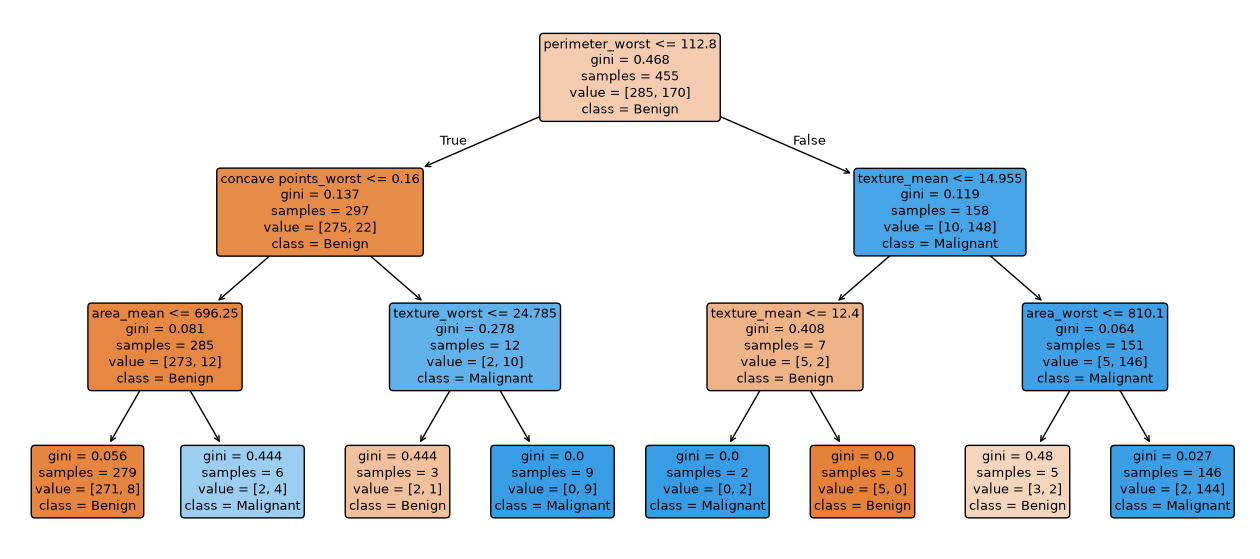

In [10]:
plt.figure(figsize=(16, 7))
plot_tree(final_tree, feature_names=X.columns, class_names=["Benign", "Malignant"],
          filled=True, rounded=True, fontsize=9)
plt.show()

**Takeaways**:

- Trees need no scaling and are easy to read: each node shows the split, its Gini impurity, and the class counts.
- An unrestricted tree memorizes the training data; limiting `max_depth` (or using `min_samples_leaf`, pruning) trades a little train accuracy for better generalization.